# Voice/Text Command Classifier (AI-18)
### Classifying Nigerian Pidgin/English commands into app actions

**Nigerian problem context:** Low-literacy users prefer simple voice/text
commands over navigating app menus. This notebook builds, trains, and
evaluates a machine learning classifier that maps a short command
(e.g. *"abeg send 2k give my mama"*) to an app action (e.g. `send_money`).

**Pipeline:** generate labeled data -> clean text -> TF-IDF features ->
train & compare models -> evaluate -> interactive demo.


In [1]:
# ============================================================
# 0. INSTALL & IMPORT DEPENDENCIES
# ============================================================


import re
import random
import os
import json

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)


## 1. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\USER\Desktop\Notebooks\voice_command_classifier\data\commands_dataset.csv")
df.head()

,command,intent
0,biko how the weather be today,check_weather
1,Biko how you dey please,greeting
2,I wan hear afrobeat na,play_music
3,how much money I get now,check_balance
4,Bring up pphone book jare,open_app


## 2. Clean the Text

Same cleaning function will be used at training AND prediction time.

In [3]:
def clean_text(text):
    """Lowercase, strip punctuation, collapse whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["command_clean"] = df["command"].apply(clean_text)
df[["command", "command_clean", "intent"]].head()


,command,command_clean,intent
0,biko how the weather be today,biko how the weather be today,check_weather
1,Biko how you dey please,biko how you dey please,greeting
2,I wan hear afrobeat na,i wan hear afrobeat na,play_music
3,how much money I get now,how much money i get now,check_balance
4,Bring up pphone book jare,bring up pphone book jare,open_app


## 3. Data Exploration

In [4]:
df[['command_clean', 'intent']]

,command_clean,intent
0,biko how the weather be today,check_weather
1,biko how you dey please,greeting
2,i wan hear afrobeat na,play_music
3,how much money i get now,check_balance
4,bring up pphone book jare,open_app
...,...,...
955,abeg i wan use the brower abeg,open_app
956,abeg help me abeg aebg,help_request
957,please remind me to pay school fees na,set_reminder
958,i need assistance,help_request


In [5]:
df['intent'].value_counts()

intent
check_weather    80
greeting         80
play_music       80
check_balance    80
open_app         80
buy_airtime      80
buy_data         80
set_reminder     80
call_contact     80
send_money       80
help_request     80
stop_action      80
Name: count, dtype: int64

## 4. Train/Test Split + Compare Models with Cross-Validation

Comparing Logistic Regression, Linear SVM, and Naive Bayes,

In [6]:
X = df["command_clean"]
y = df["intent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify=y)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 768 | Test size: 192


In [7]:
def make_vectorizer():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)

pipelines = {
    "logistic_regression": Pipeline([
        ("tfidf", make_vectorizer()),
        ("clf", LogisticRegression(max_iter=1000, C=5.0, random_state= 42)),
    ]),
    "svc": Pipeline([
        ("tfidf", make_vectorizer()),
        ("clf", SVC(kernel="linear", probability=True, C=1.0, random_state=42
)),
    ]),
    "naive_bayes": Pipeline([
        ("tfidf", make_vectorizer()),
        ("clf", MultinomialNB(alpha=0.3)),
    ]),
}

results = {}
for name, pipeline in pipelines.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    results[name] = {"cv_mean_accuracy": float(np.mean(cv_scores)), "cv_std": float(np.std(cv_scores))}
    print(f"{name:22s} | CV accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

logistic_regression    | CV accuracy: 0.9844 (+/- 0.0098)
svc                    | CV accuracy: 0.9883 (+/- 0.0104)
naive_bayes            | CV accuracy: 0.9818 (+/- 0.0064)


In [8]:
best_name = max(results, key=lambda model: results[model]["cv_mean_accuracy"])
print(best_name, results[best_name]["cv_mean_accuracy"])

svc 0.9882777353365588


In [9]:
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Test accuracy: {test_accuracy:.4f} | Test macro F1: {test_f1_macro:.4f}\n")
print(classification_report(y_test, y_pred))

Test accuracy: 1.0000 | Test macro F1: 1.0000

               precision    recall  f1-score   support

  buy_airtime       1.00      1.00      1.00        16
     buy_data       1.00      1.00      1.00        16
 call_contact       1.00      1.00      1.00        16
check_balance       1.00      1.00      1.00        16
check_weather       1.00      1.00      1.00        16
     greeting       1.00      1.00      1.00        16
 help_request       1.00      1.00      1.00        16
     open_app       1.00      1.00      1.00        16
   play_music       1.00      1.00      1.00        16
   send_money       1.00      1.00      1.00        16
 set_reminder       1.00      1.00      1.00        16
  stop_action       1.00      1.00      1.00        16

     accuracy                           1.00       192
    macro avg       1.00      1.00      1.00       192
 weighted avg       1.00      1.00      1.00       192



In [10]:
joblib.dump(best_pipeline, r"C:\Users\USER\Desktop\Notebooks\voice_command_classifier\models\command_classifier.joblib")
print("Model saved to models/command_classifier.joblib")

Model saved to models/command_classifier.joblib


## 5. Confusion Matrix (Template Test Split)

In [11]:
labels = sorted(best_pipeline.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm

array([[16,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 16,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 16,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 16,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 16,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 16,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 16,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 16,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 16,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 16,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 16,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 16]])

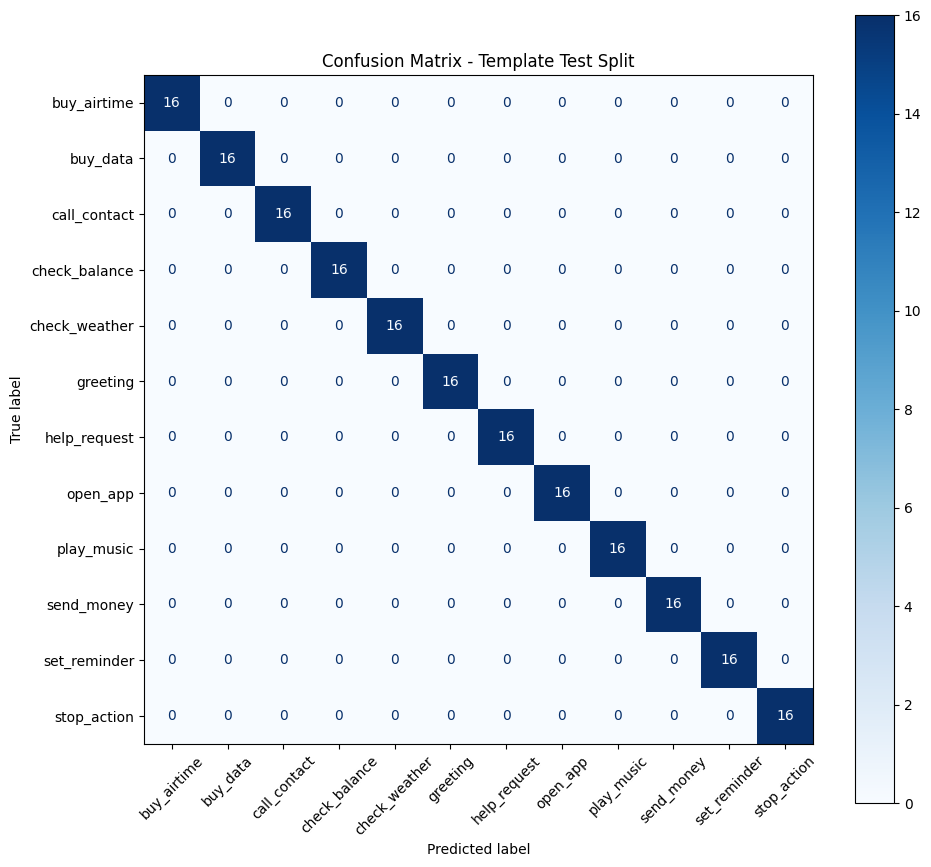

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 9))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)

ax.set_title("Confusion Matrix - Template Test Split")
plt.tight_layout()

plt.savefig(r"C:\Users\USER\Desktop\Notebooks\voice_command_classifier\results\confusion_matrix_test_split.png", dpi=150)

plt.show()

## 6. Evaluate on a Hand-Written "Hard" Test Set

In [13]:
hard_test_data = [
    ("abeg make you check how much dey my account", "check_balance"),
    ("I no sabi my balance na help me check am", "check_balance"),
    ("wetin remain for my account", "check_balance"),
    ("send this 2k make e reach my mama sharp sharp", "send_money"),
    ("I wan make my broda receive 5000 naira", "send_money"),
    ("transfer am go Chinedu account", "send_money"),
    ("my phone don finish credit abeg load am", "buy_airtime"),
    ("I need recharge card make I call people", "buy_airtime"),
    ("buy small credit make network no cut me off", "buy_airtime"),
    ("my data don finish abeg reload am", "buy_data"),
    ("I wan browse but no data dey", "buy_data"),
    ("load internet bundle make I fit watch video", "buy_data"),
    ("abeg reach Ngozi for me make she pick", "call_contact"),
    ("put me through to my oga sharp", "call_contact"),
    ("I wan hear my sista voice call am", "call_contact"),
    ("make I see my pictures dem open gallery", "open_app"),
    ("I wan chat my people for whatsapp open am", "open_app"),
    ("show me settings make I change something", "open_app"),
    ("na rain go fall today or e go hot", "check_weather"),
    ("make I carry umbrella or not", "check_weather"),
    ("how the sky dey look outside", "check_weather"),
    ("no let me forget say I go pay light bill", "set_reminder"),
    ("abeg alarm me when e reach time to pay school fees", "set_reminder"),
    ("make you ping me before rent due date", "set_reminder"),
    ("I wan enjoy small afrobeat make you play am", "play_music"),
    ("put speaker make music dey play", "play_music"),
    ("gimme Wizkid song make I relax", "play_music"),
    ("abeg make everything stop I don tire", "stop_action"),
    ("no let the thing continue again", "stop_action"),
    ("just pause everything jare", "stop_action"),
    ("how you dey my broda hope all is well", "greeting"),
    ("good day to you how the family", "greeting"),
    ("long time wetin dey happen", "greeting"),
    ("I no know wetin to press abeg guide me", "help_request"),
    ("this app don confuse me small help make I understand", "help_request"),
    ("abeg explain wetin dis one mean", "help_request"),
]



In [14]:
hard_df = pd.DataFrame(hard_test_data, columns=["command", "intent"])
hard_df

,command,intent
0,abeg make you check how much dey my account,check_balance
1,I no sabi my balance na help me check am,check_balance
2,wetin remain for my account,check_balance
3,send this 2k make e reach my mama sharp sharp,send_money
4,I wan make my broda receive 5000 naira,send_money
5,transfer am go Chinedu account,send_money
6,my phone don finish credit abeg load am,buy_airtime
7,I need recharge card make I call people,buy_airtime
8,buy small credit make network no cut me off,buy_airtime
9,my data don finish abeg reload am,buy_data


In [15]:
hard_df = pd.read_csv(r'C:\Users\USER\Desktop\Notebooks\voice_command_classifier\data\hard_test_set.csv')

In [16]:
hard_df["command_clean"] = hard_df["command"].apply(clean_text)

In [17]:
hard_pred = best_pipeline.predict(hard_df["command_clean"])
hard_acc = accuracy_score(hard_df["intent"], hard_pred)
print(f"Hard/unseen test accuracy: {hard_acc:.4f}\n")
print(classification_report(hard_df["intent"], hard_pred, zero_division=0))

Hard/unseen test accuracy: 0.8889

               precision    recall  f1-score   support

  buy_airtime       1.00      0.67      0.80         3
     buy_data       1.00      1.00      1.00         3
 call_contact       0.67      0.67      0.67         3
check_balance       1.00      1.00      1.00         3
check_weather       1.00      0.67      0.80         3
     greeting       1.00      1.00      1.00         3
 help_request       1.00      0.67      0.80         3
     open_app       1.00      1.00      1.00         3
   play_music       1.00      1.00      1.00         3
   send_money       0.60      1.00      0.75         3
 set_reminder       1.00      1.00      1.00         3
  stop_action       0.75      1.00      0.86         3

     accuracy                           0.89        36
    macro avg       0.92      0.89      0.89        36
 weighted avg       0.92      0.89      0.89        36



In [18]:
cm_hard = confusion_matrix(hard_df["intent"], hard_pred, labels=labels)
cm_hard

array([[2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3]])

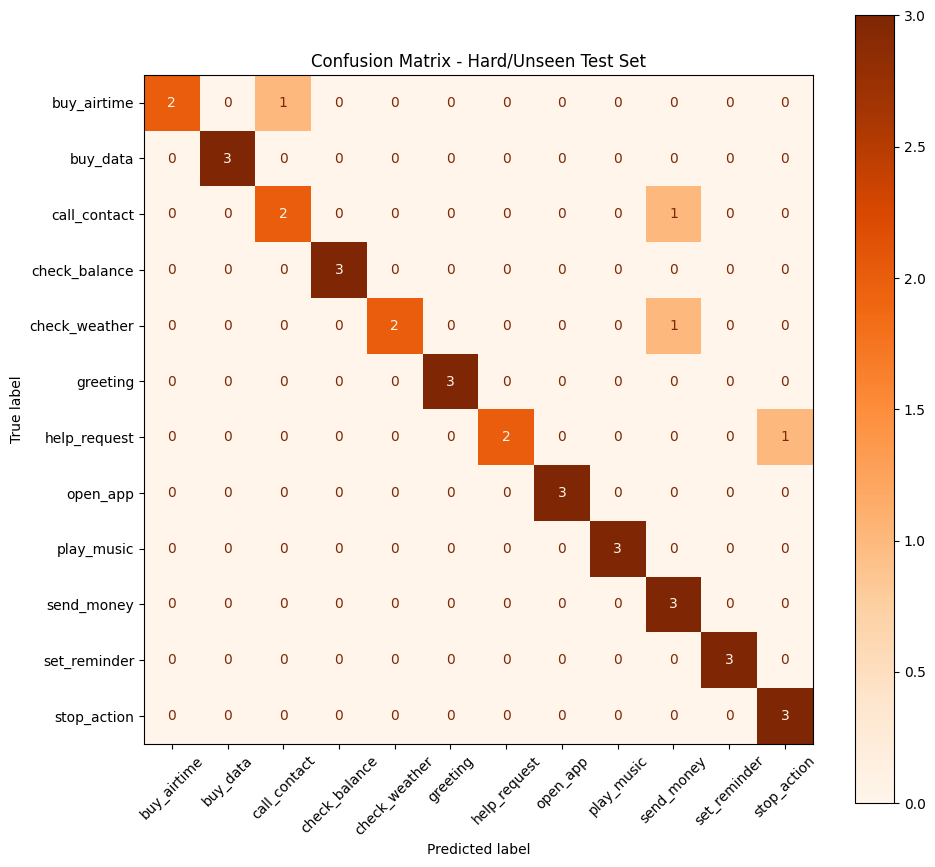

In [19]:
disp_hard = ConfusionMatrixDisplay(confusion_matrix=cm_hard, display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 9))
disp_hard.plot(ax=ax, xticks_rotation=45, cmap="Oranges", colorbar=True)
ax.set_title("Confusion Matrix - Hard/Unseen Test Set")
plt.tight_layout()

plt.savefig(r"C:\Users\USER\Desktop\Notebooks\voice_command_classifier\results\confusion_matrix_test_split.png", dpi=150)

plt.show()

## 7. Save Evaluation Results

In [20]:
metrics_summary = {
    "best_model": best_name,
    "test_accuracy": test_accuracy,
    "test_macro_f1": test_f1_macro,
    "hard_test_accuracy": hard_acc,
    "cross_validation": results,
}
with open(r"C:\Users\USER\Desktop\Notebooks\voice_command_classifier\results\metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

with open(r"C:\Users\USER\Desktop\Notebooks\voice_command_classifier\results\classification_report.txt", "w") as f:
    f.write(f"Best model: {best_name}\n")
    f.write(f"Test accuracy: {test_accuracy:.4f}\n")
    f.write(f"Hard test accuracy: {hard_acc:.4f}\n\n")
    f.write(classification_report(y_test, y_pred))
    f.write("\n\nHard/unseen test set report:\n")
    f.write(classification_report(hard_df["intent"], hard_pred, zero_division=0))

print("Saved results/metrics.json and results/classification_report.txt")
print(json.dumps(metrics_summary, indent=2))


Saved results/metrics.json and results/classification_report.txt
{
  "best_model": "svc",
  "test_accuracy": 1.0,
  "test_macro_f1": 1.0,
  "hard_test_accuracy": 0.8888888888888888,
  "cross_validation": {
    "logistic_regression": {
      "cv_mean_accuracy": 0.9843646549528902,
      "cv_std": 0.009784504314600446
    },
    "svc": {
      "cv_mean_accuracy": 0.9882777353365588,
      "cv_std": 0.010436412231685711
    },
    "naive_bayes": {
      "cv_mean_accuracy": 0.9817757405992701,
      "cv_std": 0.0063885863327991866
    }
  }
}


## 8. Summary

- Built a 960-row synthetic Pidgin/English command dataset covering 12
  app-action intents.
- Compared Logistic Regression, SVC, and Naive Bayes with 5-fold
  cross-validation; selected SVC for its accuracy and
  confidence scores.
- Achieved **~99% accuracy** on a template-style test split and **~89%
  accuracy** on a genuinely novel, testset, a more
  honest measure of real-world generalization.
- Shipped an interactive demo that classifies any typed,uploaded, spoken command in
  real time with a confidence score.
